In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = np.array([0, 1, 3, 4, 6, 7, 8]) # Years of experience
y = np.array([5, 15, 35, 45, 65, 75, 95]) # Salary in thousands

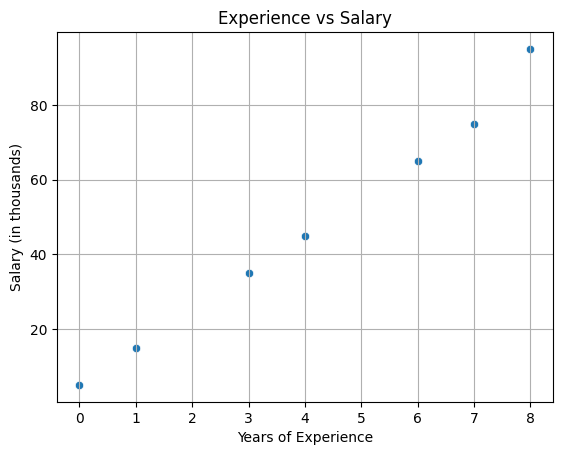

In [3]:
sns.scatterplot(x = X, y = y)
plt.xlabel('Years of Experience')
plt.ylabel('Salary (in thousands)')
plt.title('Experience vs Salary')
plt.grid()
plt.show()

In [4]:
def make_prediction(X, y, w, b):
    m = X.shape[0]

    pred_list = np.zeros((m,))
    for i in range(m):
        pred_list[i] = w * X[i] + b
    return pred_list

[0. 0. 0. 0. 0. 0. 0.]


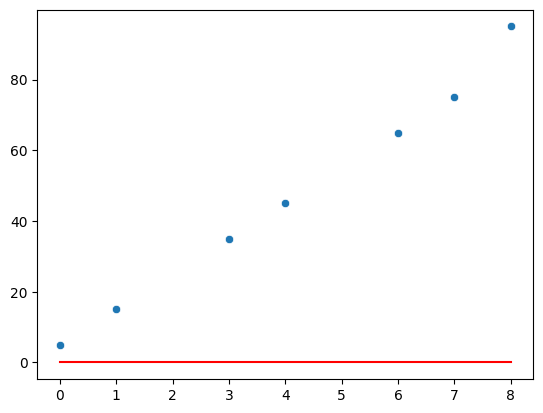

In [5]:
predictions = make_prediction(X, y, w = 0, b = 0)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')

[0. 1. 3. 4. 6. 7. 8.]


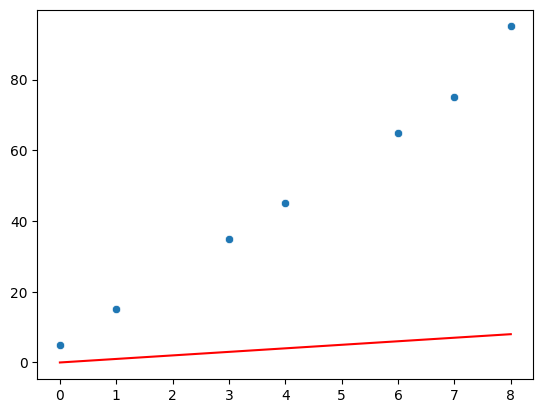

In [6]:
predictions = make_prediction(X, y, w = 1, b = 0)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')

[ 1.  6. 16. 21. 31. 36. 41.]


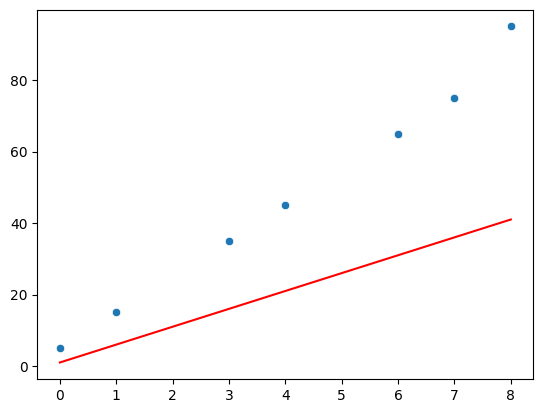

In [7]:
predictions = make_prediction(X, y, w = 5, b = 1)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')

[ 0. 10. 30. 40. 60. 70. 80.]


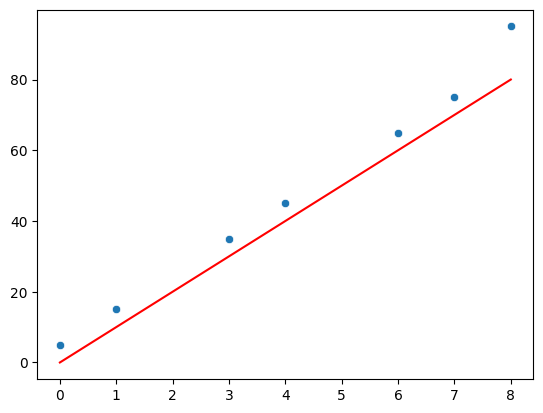

In [8]:
predictions = make_prediction(X, y, w = 10, b = 0)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')

[ 4. 14. 34. 44. 64. 74. 84.]


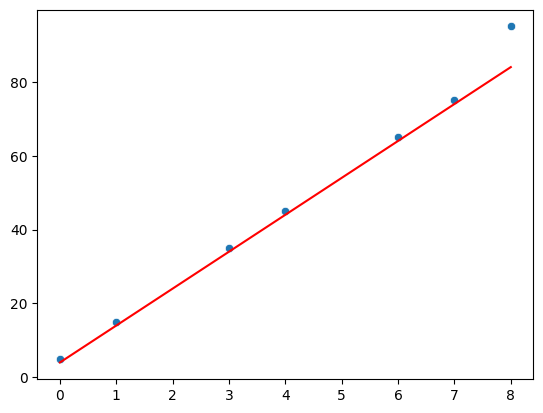

In [9]:
predictions = make_prediction(X, y, w = 10, b = 4)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')

[ 6. 16. 36. 46. 66. 76. 86.]


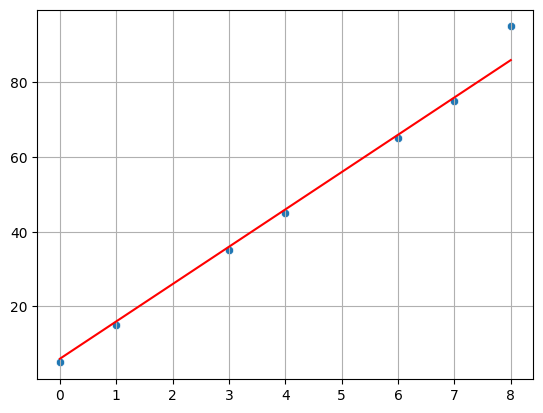

In [10]:
predictions = make_prediction(X, y, w = 10, b = 6)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')
plt.grid()

In [11]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost += error_squared

    cost = cost / m
    return cost




[ 6. 16. 36. 46. 66. 76. 86.]


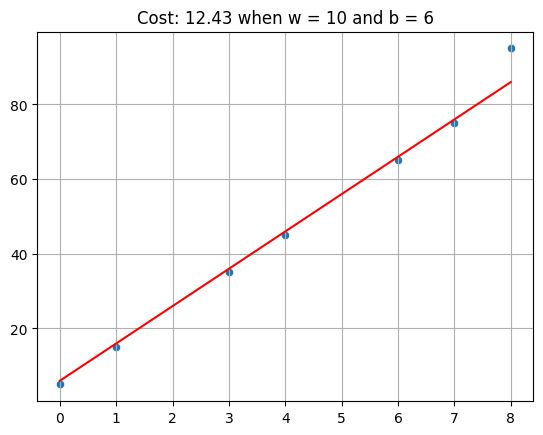

In [15]:

w = 10
b = 6
predictions = make_prediction(X, y, w = w, b = b)
print(predictions)
sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')
plt.title(f"Cost: {compute_cost(X, y, w = w, b = b):.2f} when w = {w} and b = {b}")
plt.grid()

[ 5. 16. 38. 49. 71. 82. 93.]


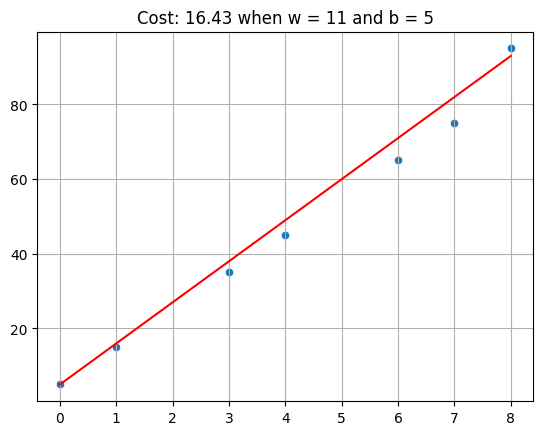

In [16]:
w = 11
b = 5
predictions = make_prediction(X, y, w = w, b = b)
print(predictions)
sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')
plt.title(f"Cost: {compute_cost(X, y, w = w, b = b):.2f} when w = {w} and b = {b}")
plt.grid()

[ 6.5 16.  35.  44.5 63.5 73.  82.5]


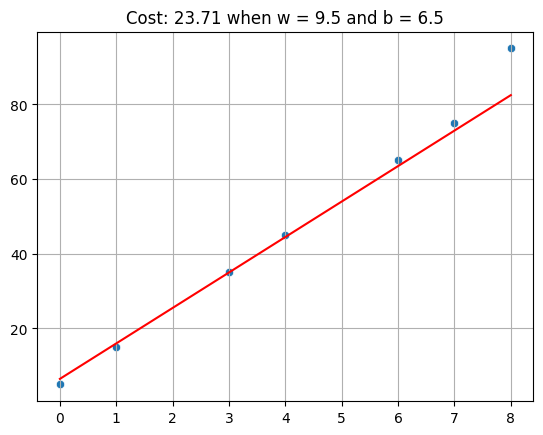

In [17]:

w = 9.5
b = 6.5
predictions = make_prediction(X, y, w = w, b = b)
print(predictions)
sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')
plt.title(f"Cost: {compute_cost(X, y, w = w, b = b):.2f} when w = {w} and b = {b}")
plt.grid()

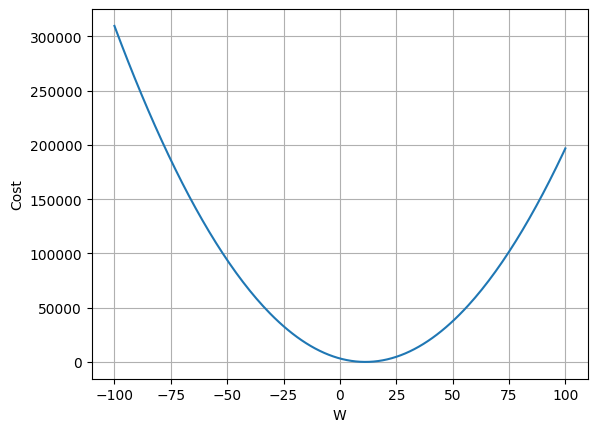

In [22]:
w = []
cost = []

for i in range(-100, 101):
    cost_i = compute_cost(X, y, w = i, b = 0)
    w.append(i)
    cost.append(cost_i)

plt.plot(w, cost)
plt.xlabel('W')
plt.ylabel('Cost')
plt.grid()
plt.show()

In [29]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]

    dj_dw = 0.0
    dj_db = 0.0

    cost = 0.0
    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    dj_dw = (dj_dw * 2) / m
    dj_db = (dj_db * 2) / m

    return dj_dw, dj_db


In [30]:
calculate_gradient(X, y, 10, 5)

(-22.857142857142858, -2.857142857142857)

In [37]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
    w = w_input
    b = b_input
    
    cost_memo = []

    iteration = []
    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        cost = compute_cost(X,y,w,b)
        cost_memo.append(cost)
        iteration.append(i)
        if i % 100 == 0:
            print(f"w:{w:.4f}, b:{b:.4f}, cost:{cost:.4f}")

        
    return w, b, cost_memo, iteration

In [41]:
w, b, memo, iter = gradient_descent(X, y, 0, 0, 1000, alpha = 0.01)

w:5.6429, b:0.9571, cost:762.3460
w:10.8544, b:2.6138, cost:8.6255
w:10.7852, b:3.0265, cost:8.4455
w:10.7476, b:3.2504, cost:8.3926
w:10.7273, b:3.3718, cost:8.3770
w:10.7162, b:3.4376, cost:8.3724
w:10.7102, b:3.4733, cost:8.3711
w:10.7070, b:3.4927, cost:8.3707
w:10.7052, b:3.5032, cost:8.3706
w:10.7043, b:3.5089, cost:8.3706


[ 3.51194148 14.21568443 35.62317033 46.32691328 67.73439918 78.43814213
 89.14188508]


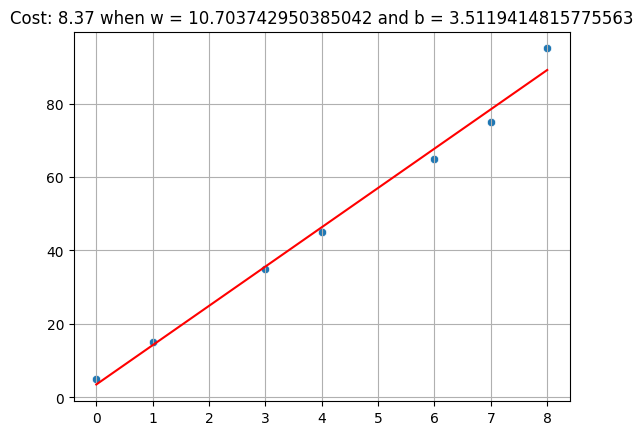

In [42]:
predictions = make_prediction(X, y, w = w, b = b)
print(predictions)
sns.scatterplot(x = X, y = y)
plt.plot(X, predictions, color = 'red')
plt.title(f"Cost: {compute_cost(X, y, w = w, b = b):.2f} when w = {w} and b = {b}")
plt.grid()

In [43]:
x = 2
prediction = w * x + b
prediction

24.91942738234764

Text(0, 0.5, 'Cost')

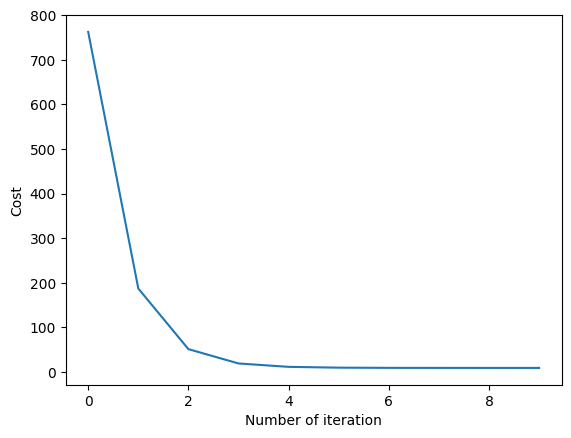

In [49]:
plt.plot(iter[:10], memo[:10])
plt.xlabel('Number of iteration')
plt.ylabel('Cost')